In [1]:
# 📦 匯入套件
from pathlib import Path
from openai import OpenAI
import json
from datetime import datetime


In [2]:
# ✅ 載入 TeleQnA JSON
TeleQnA = "/home/aiml/johnson/testing_llm_5g_understand/branchmark/TeleQnA/TeleQnA.txt"
with open(TeleQnA, "r", encoding="utf-8") as f:
    teleqna_data = json.load(f)

# 顯示一筆資料範例
sample_key = list(teleqna_data.keys())[0]
teleqna_data[sample_key]

{'question': 'What is the purpose of the Nmfaf_3daDataManagement_Deconfigure service operation? [3GPP Release 18]',
 'option 1': 'To configure the MFAF to map data or analytics received by the MFAF to out-bound notification endpoints',
 'option 2': 'To configure the MFAF to stop mapping data or analytics received by the MFAF to out-bound notification endpoints',
 'option 3': 'To supply data or analytics from the MFAF to notification endpoints',
 'option 4': 'To fetch data or analytics from the MFAF based on fetch instructions',
 'answer': 'option 2: To configure the MFAF to stop mapping data or analytics received by the MFAF to out-bound notification endpoints',
 'explanation': 'The Nmfaf_3daDataManagement_Deconfigure service operation is used to stop mapping data or analytics received by the MFAF to one or more out-bound notification endpoints.',
 'category': 'Standards specifications'}

In [3]:
# === 呼叫 NVIDIA LLM API ===
def call_nvidia_llm(prompt: str) -> str:
    client = OpenAI(
        base_url="https://integrate.api.nvidia.com/v1",
        api_key="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"
    )

    response = client.chat.completions.create(
        model="meta/llama3-70b-instruct",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.5,
        top_p=0.7,
        max_tokens=1024,
        stream=False
    )

    return response.choices[0].message.content

In [4]:
# 📤 生成 prompt 並取得回應
def generate_prompt(entry: dict) -> str:
    prompt = f"""You are a telecom expert. Please answer the following multiple choice question with an explanation.

Question: {entry['question']}

Options:
(A) {entry['option 1']}
(B) {entry['option 2']}
(C) {entry['option 3']}
(D) {entry['option 4']}

Please provide:
1. The correct option (A/B/C/D)
2. A brief explanation.
"""
    return prompt

In [5]:
# 🔄 測試一筆資料
entry = teleqna_data["question 2"]
prompt = generate_prompt(entry)
llm_response = call_nvidia_llm(prompt)
print("LLM 回應內容:\n", llm_response)

LLM 回應內容:
 The correct option is:

(C) 2

Explanation:

The Alamouti scheme is a space-time block coding (STBC) technique used in multiple-input multiple-output (MIMO) systems. It is a transmit diversity scheme that provides a diversity gain of 2 for the detection of each symbol.

In the Alamouti scheme, two antennas are used at the transmitter, and two symbols are transmitted simultaneously over two time slots. The receiver uses the received signals from both time slots to detect each symbol. The diversity gain of 2 comes from the fact that each symbol is effectively transmitted over two independent channels, providing two independent observations of the symbol. This allows the receiver to combine the two observations to improve the detection reliability, resulting in a diversity gain of 2.

Therefore, the correct answer is option (C) 2.


In [6]:
# 🔍 比對 LLM 回答與正解
from difflib import SequenceMatcher

def match_option(llm_output: str, correct_answer: str) -> dict:
    correct_option = correct_answer.split(":")[0].strip().split()[-1]  # option 3 → 3
    correct_letter = chr(ord("A") + int(correct_option) - 1)  # 3 → C

    llm_guess = "?"
    for letter in ["A", "B", "C", "D"]:
        if f"({letter})" in llm_output or f"Option {letter}" in llm_output or f"Answer: {letter}" in llm_output:
            llm_guess = letter
            break

    is_correct = (llm_guess == correct_letter)

    return {
        "llm_guess": llm_guess,
        "correct_letter": correct_letter,
        "is_correct": is_correct,
        "llm_explanation": llm_output
    }

match_result = match_option(llm_response, entry["answer"])
match_result

{'llm_guess': 'C',
 'correct_letter': 'C',
 'is_correct': True,
 'llm_explanation': 'The correct option is:\n\n(C) 2\n\nExplanation:\n\nThe Alamouti scheme is a space-time block coding (STBC) technique used in multiple-input multiple-output (MIMO) systems. It is a transmit diversity scheme that provides a diversity gain of 2 for the detection of each symbol.\n\nIn the Alamouti scheme, two antennas are used at the transmitter, and two symbols are transmitted simultaneously over two time slots. The receiver uses the received signals from both time slots to detect each symbol. The diversity gain of 2 comes from the fact that each symbol is effectively transmitted over two independent channels, providing two independent observations of the symbol. This allows the receiver to combine the two observations to improve the detection reliability, resulting in a diversity gain of 2.\n\nTherefore, the correct answer is option (C) 2.'}

In [7]:
import time
from openai import OpenAI

def evaluate_model_on_teleqna(model_name: str, num_questions: int = 10, delay_sec: int = 2):
    print(f"\n🚀 Testing model: {model_name}")
    client = OpenAI(
        base_url="https://integrate.api.nvidia.com/v1",
        api_key="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"
    )

    correct_count = 0
    results = []
    all_keys = list(teleqna_data.keys())[:num_questions]

    for idx, key in enumerate(all_keys, start=1):
        entry = teleqna_data[key]
        prompt = generate_prompt(entry)
        try:
            response = client.chat.completions.create(
                model=model_name,
                messages=[{"role": "user", "content": prompt}],
                temperature=0.5,
                top_p=0.7,
                max_tokens=1024,
                stream=False
            )
            llm_response = response.choices[0].message.content

            result = match_option(llm_response, entry["answer"])
            result["question_key"] = key
            results.append(result)

            if result["is_correct"]:
                correct_count += 1

            current_accuracy = correct_count / idx
            status = "✅ Correct" if result["is_correct"] else "❌ Wrong"
            print(f"[{idx:02}] {status} | Guess: {result['llm_guess']} | Ans: {result['correct_letter']} | Acc: {current_accuracy:.2%}")
        except Exception as e:
            print(f"[{idx:02}] ⚠️ Error in question {key}: {e}")
            results.append({"question_key": key, "error": str(e)})

        time.sleep(delay_sec)

    final_accuracy = correct_count / len(all_keys)
    print(f"🎯 Final Accuracy for {model_name}: {final_accuracy:.2%}")
    return {
        "model": model_name,
        "accuracy": final_accuracy,
        "results": results
    }


In [8]:
candidate_models = [
"meta/llama-3.1-405b-instruct",
"meta/llama-3.1-70b-instruct",
"meta/llama-3.1-8b-instruct",
# "qwen/qwen2-7b-instruct",
# "qwen/qwen2.5-7b-instruct",
# "qwen/qwq-32b"
]

none_rag_results = []
for model in candidate_models:
    result = evaluate_model_on_teleqna(model_name=model, num_questions=20, delay_sec=0.5)
    none_rag_results.append(result)


data_to_save = none_rag_results

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
json_path = Path(f"/home/aiml/johnson/testing_llm_5g_understand/result/none_RAG_evaluation_results_{timestamp}.json")

with open(json_path, "w", encoding="utf-8") as f:
    json.dump(data_to_save, f, ensure_ascii=False, indent=2)

print(f"✅ Saved to: {json_path}")


🚀 Testing model: meta/llama-3.1-405b-instruct


[01] ❌ Wrong | Guess: ? | Ans: B | Acc: 0.00%


[02] ❌ Wrong | Guess: A | Ans: E | Acc: 0.00%


[03] ✅ Correct | Guess: C | Ans: C | Acc: 33.33%


[04] ✅ Correct | Guess: D | Ans: D | Acc: 50.00%


...

[17] ❌ Wrong | Guess: A | Ans: E | Acc: 47.06%


[18] ✅ Correct | Guess: C | Ans: C | Acc: 50.00%


[19] ✅ Correct | Guess: A | Ans: A | Acc: 52.63%


[20] ❌ Wrong | Guess: D | Ans: B | Acc: 50.00%


🎯 Final Accuracy for meta/llama-3.1-8b-instruct: 50.00%
✅ Saved to: /home/aiml/johnson/testing_llm_5g_understand/result/none_RAG_evaluation_results_20250721_214414.json


,model,accuracy
0,meta/llama-3.1-405b-instruct,0.60
1,meta/llama-3.1-70b-instruct,0.55
2,meta/llama-3.1-8b-instruct,0.50


/home/aiml/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


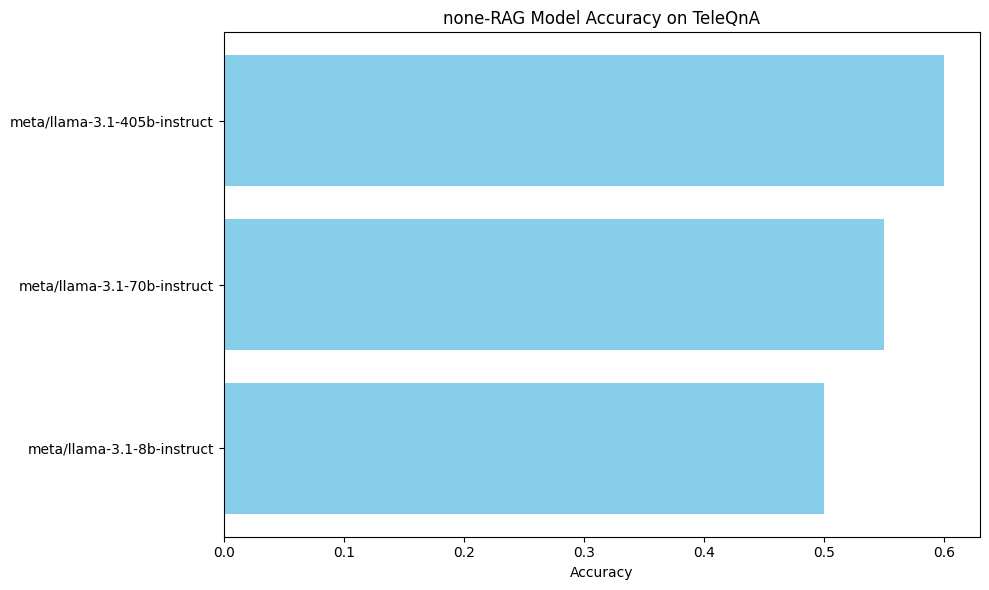

In [9]:
import pandas as pd
all_evaluation_results_for_chart = [
    {"model": result["model"], "accuracy": result["accuracy"]}
    for result in none_rag_results
]

# 用於表格與圖表
df = pd.DataFrame(all_evaluation_results_for_chart)
df = df.sort_values(by="accuracy", ascending=False).reset_index(drop=True)

# 顯示表格
display(df)

# 繪製長條圖
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(df["model"], df["accuracy"], color="skyblue")
plt.xlabel("Accuracy")
plt.title("none-RAG Model Accuracy on TeleQnA")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [10]:
from langchain.vectorstores import Chroma
from langchain_huggingface import HuggingFaceEmbeddings

embedding = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vectordb = Chroma(persist_directory="/home/aiml/johnson/thesis_rag/3gpp_db_1100", embedding_function=embedding)

def retrieve_context(question, top_k=3):
    results = vectordb.similarity_search(question, k=top_k)
    context = "\n".join([doc.page_content for doc in results])
    return context


2025-07-21 21:44:16.167140: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-21 21:44:16.185489: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-21 21:44:16.185510: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-21 21:44:16.186197: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-21 21:44:16.189815: I tensorflow/core/platform/cpu_feature_guar

2025-07-21 21:44:16.606168: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


/tmp/ipykernel_633563/4148874482.py:5: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-chroma package and should be used instead. To use it run `pip install -U :class:`~langchain-chroma` and import as `from :class:`~langchain_chroma import Chroma``.
  vectordb = Chroma(persist_directory="/home/aiml/johnson/thesis_rag/3gpp_db_1100", embedding_function=embedding)


In [11]:
from openai import OpenAI
import time

def evaluate_model_on_teleqna_with_rag(model_name: str, num_questions: int = 20, delay_sec: int = 0.5):
    print(f"\n🔍 Testing model with RAG: {model_name}")
    client = OpenAI(
        base_url="https://integrate.api.nvidia.com/v1",
        api_key="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"
    )

    correct_count = 0
    results = []
    all_keys = list(teleqna_data.keys())[:num_questions]

    for idx, key in enumerate(all_keys, start=1):
        entry = teleqna_data[key]
        context = retrieve_context(entry["question"])

        prompt = f"""You are a telecom expert. Use the background context to help answer the question.

        Answer the question as accurately as possible. If the context clearly supports the answer, mention that in the explanation.
        If the context does not help or is irrelevant, mention that the answer is based on general telecom knowledge.

        Background context:
        {context}

        Question: {entry['question']}

        Options:
        (A) {entry['option 1']}
        (B) {entry['option 2']}
        (C) {entry['option 3']}
        (D) {entry['option 4']}

        Please provide:
        1. Answer: (A/B/C/D)
        2. Explanation: Clearly state whether the answer is based on the background context or on general telecom knowledge.
        """




        try:
            response = client.chat.completions.create(
                model=model_name,
                messages=[{"role": "user", "content": prompt}],
                temperature=0.5,
                top_p=0.7,
                max_tokens=1024,
                stream=False
            )
            llm_response = response.choices[0].message.content
            result = match_option(llm_response, entry["answer"])
            result["question_key"] = key
            results.append(result)

            if result["is_correct"]:
                correct_count += 1

            acc = correct_count / idx
            print(f"[{idx:02}] {'✅' if result['is_correct'] else '❌'} | Guess: {result['llm_guess']} | Ans: {result['correct_letter']} | Acc: {acc:.2%}")
        except Exception as e:
            print(f"[{idx:02}] ⚠️ Error: {e}")
            results.append({"question_key": key, "error": str(e)})

        time.sleep(delay_sec)

    final_acc = correct_count / len(all_keys)
    print(f"🎯 Final RAG Accuracy for {model_name}: {final_acc:.2%}")
    return {"model": model_name, "accuracy": final_acc, "results": results}

In [12]:
candidate_models = [
"meta/llama-3.1-405b-instruct",
"meta/llama-3.1-70b-instruct",
"meta/llama-3.1-8b-instruct",
# "qwen/qwen2-7b-instruct",
# "qwen/qwen2.5-7b-instruct",
# "qwen/qwq-32b"
]
rag_results = []
for model in candidate_models:
    result = evaluate_model_on_teleqna_with_rag(model_name=model, num_questions=20, delay_sec=0.5)
    rag_results.append(result)



data_to_save = rag_results 

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
json_path = Path(f"/home/aiml/johnson/testing_llm_5g_understand/result/RAG_evaluation_results_{timestamp}.json")

with open(json_path, "w", encoding="utf-8") as f:
    json.dump(data_to_save, f, ensure_ascii=False, indent=2)

print(f"✅ Saved to: {json_path}")


🔍 Testing model with RAG: meta/llama-3.1-405b-instruct


[01] ✅ | Guess: B | Ans: B | Acc: 100.00%


[02] ❌ | Guess: C | Ans: E | Acc: 50.00%


[03] ✅ | Guess: C | Ans: C | Acc: 66.67%


[04] ✅ | Guess: D | Ans: D | Acc: 75.00%


...

[17] ❌ | Guess: C | Ans: E | Acc: 35.29%


[18] ✅ | Guess: C | Ans: C | Acc: 38.89%


[19] ✅ | Guess: A | Ans: A | Acc: 42.11%


[20] ❌ | Guess: A | Ans: B | Acc: 40.00%


🎯 Final RAG Accuracy for meta/llama-3.1-8b-instruct: 40.00%
✅ Saved to: /home/aiml/johnson/testing_llm_5g_understand/result/RAG_evaluation_results_20250721_214903.json


,model,accuracy
0,meta/llama-3.1-405b-instruct,0.75
1,meta/llama-3.1-70b-instruct,0.55
2,meta/llama-3.1-8b-instruct,0.40


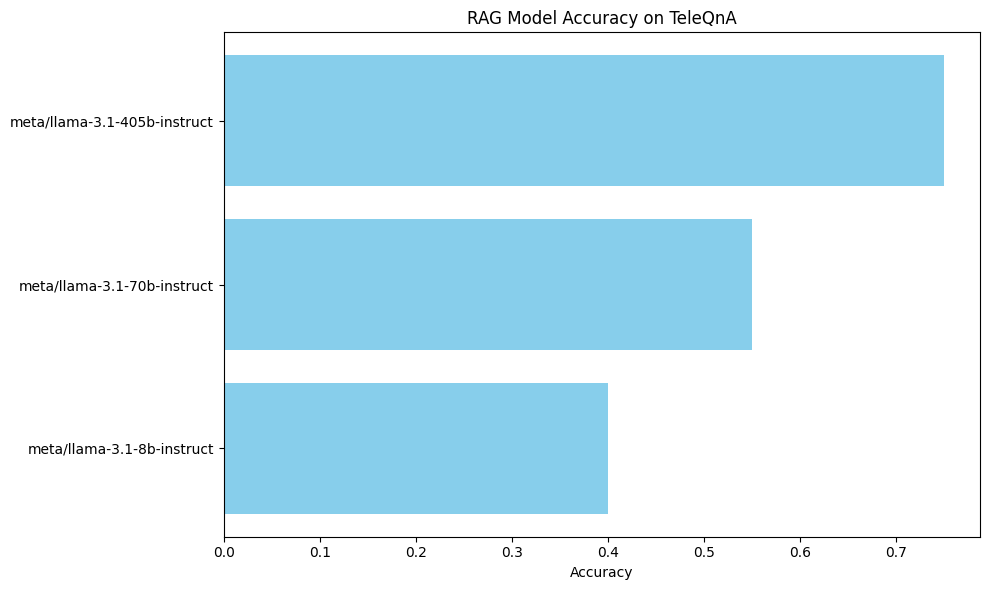

In [13]:
import pandas as pd
rag_results_for_chart = [
    {"model": result["model"], "accuracy": result["accuracy"]}
    for result in rag_results
]



# 用於表格與圖表
df = pd.DataFrame(rag_results_for_chart)
df = df.sort_values(by="accuracy", ascending=False).reset_index(drop=True)

# 顯示表格
display(df)

# 繪製長條圖
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(df["model"], df["accuracy"], color="skyblue")
plt.xlabel("Accuracy")
plt.title("RAG Model Accuracy on TeleQnA")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


[{'model': 'meta/llama-3.1-405b-instruct', 'accuracy': 0.75, 'results': [{'llm_guess': 'B', 'correct_letter': 'B', 'is_correct': True, 'llm_explanation': '1. Answer: (B)\n\n2. Explanation: The answer is based on general telecom knowledge, specifically knowledge of 3GPP Release 18. The Nmfaf_3daDataManagement_Deconfigure service operation is likely used to reverse or undo a configuration setting. In this case, the "Deconfigure" part of the operation name suggests that it is used to stop or remove a configuration. Option (B) is the most plausible answer, as it involves stopping the mapping of data or analytics to out-bound notification endpoints, which aligns with the concept of deconfiguring a setting.\n\nNote: Without specific background context, I relied on general knowledge of telecom operations and the naming convention of the service operation to arrive at this answer.', 'question_key': 'question 0'}, {'llm_guess': 'C', 'correct_letter': 'E', 'is_correct': False, 'llm_explanation':

type,None-RAG,RAG
model,,
meta/llama-3.1-405b-instruct,0.60,0.75
meta/llama-3.1-70b-instruct,0.55,0.55
meta/llama-3.1-8b-instruct,0.50,0.40


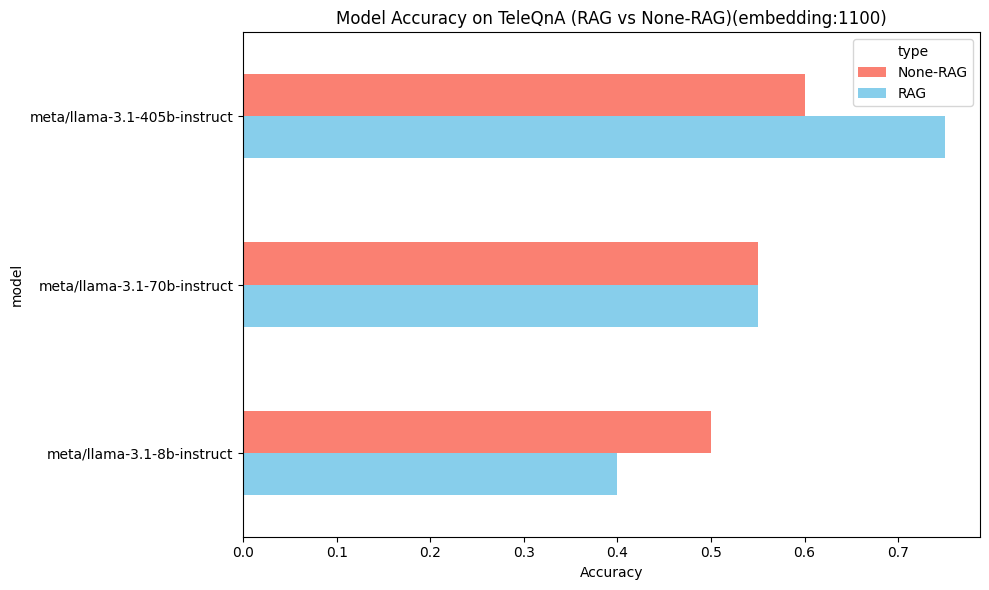

✅ Image saved to: /home/aiml/johnson/testing_llm_5g_understand/result/accuracy_comparison.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

print(rag_results)

print(none_rag_results)
# 1. 建立表格資料
rag_results_for_chart = [
    {"model": result["model"], "accuracy": result["accuracy"], "type": "RAG"}
    for result in rag_results
]

none_rag_results_for_chart = [
    {"model": result["model"], "accuracy": result["accuracy"], "type": "None-RAG"}
    for result in none_rag_results
]

# 2. 合併兩者結果
combined_df = pd.DataFrame(rag_results_for_chart + none_rag_results_for_chart)

# 3. 用 pivot 方式轉為寬表格（方便畫圖）
pivot_df = combined_df.pivot(index="model", columns="type", values="accuracy").fillna(0)

# 4. 顯示表格
display(pivot_df)

# 5. 繪圖：使用雙色長條圖
pivot_df = pivot_df.sort_values(by="RAG", ascending=False)  # 可根據 RAG 或 None-RAG 排序

ax = pivot_df.plot(kind="barh", figsize=(10, 6), color={"RAG": "skyblue", "None-RAG": "salmon"})
plt.xlabel("Accuracy")
plt.title("Model Accuracy on TeleQnA (RAG vs None-RAG)(embedding:1100)")
plt.gca().invert_yaxis()
plt.tight_layout()

# ✅ 儲存圖片
output_path = "/home/aiml/johnson/testing_llm_5g_understand/result/1100_accuracy_comparison.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()
print(f"✅ Image saved to: {output_path}")

plt.show()
